## Task 1
# Problem Identification

This dataset represents an **Image Classification** problem.

Reason:
- Each image belongs to exactly one defect category.
- The goal is to classify the product image into one of four classes:
  - normal
  - scratch
  - dent
  - stain

The task does not require locating defects using bounding boxes (object detection) or pixel-level masks (segmentation). Therefore, image classification is the most appropriate computer vision problem type.

In [2]:
## Task 2
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
## Loading Labels
labels_df = pd.read_csv("labels.csv")

labels_df.head()

,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [5]:
## Number of classes
print("Classes:")
print(labels_df["class"].unique())

print("\nNumber of Classes:")
print(labels_df["class"].nunique())

Classes:
<StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str

Number of Classes:
4


class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


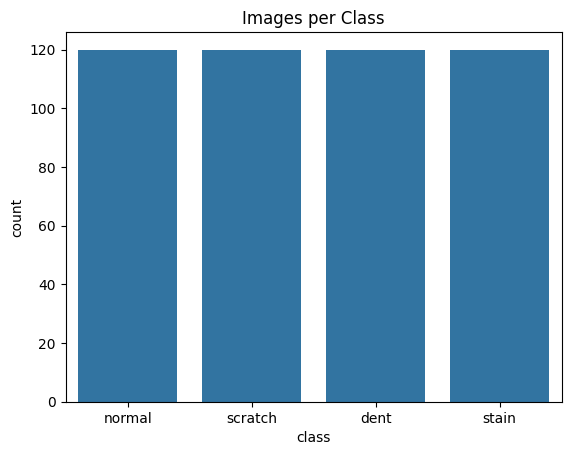

In [7]:
## Image per class
class_counts = labels_df["class"].value_counts()

print(class_counts)

sns.countplot(x="class", data=labels_df)
plt.title("Images per Class")
plt.show()

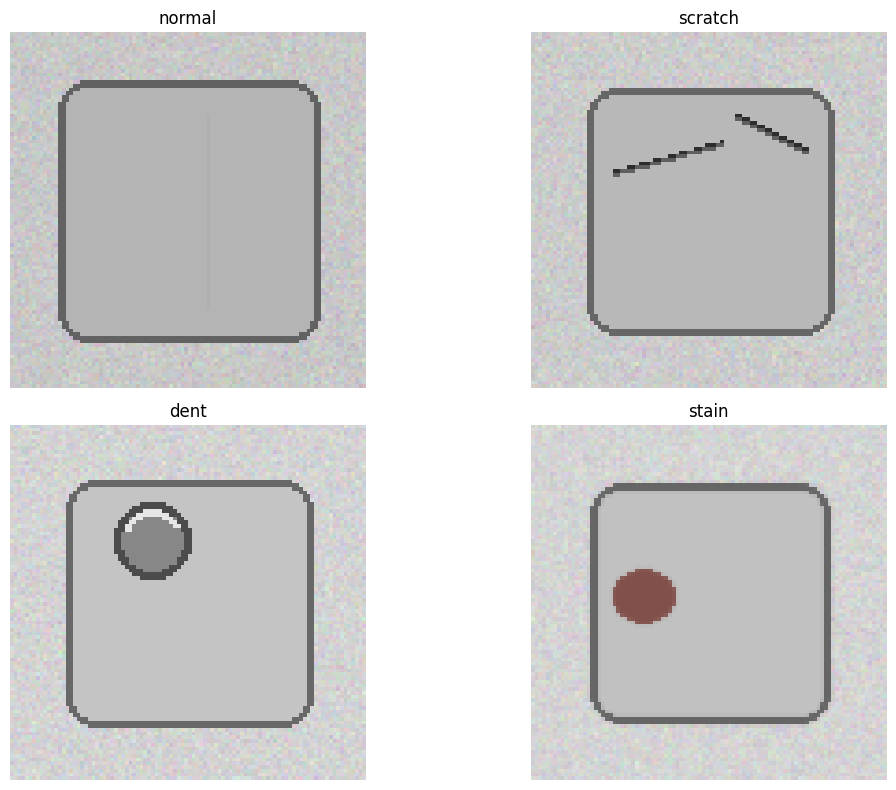

In [11]:
## Sample images
classes = labels_df["class"].unique()

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    sample_path = labels_df[labels_df["class"] == cls].iloc[0]["filename"]

    img = cv2.imread(sample_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
## Image dimension
sample_img = cv2.imread(labels_df.iloc[0]["filename"])

print("Image Shape:", sample_img.shape)

Image Shape: (96, 96, 3)


- The dataset contains four image classes.
- Images represent different manufacturing surface conditions.
- Class distribution helps identify imbalance.
- Image dimensions may vary and therefore resizing is required before CNN training.

In [14]:
## Task 3
## Resize & normalizing images
IMG_SIZE = 128

images = []
labels = []

for _, row in labels_df.iterrows():

    img = cv2.imread(row["filename"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    images.append(img)
    labels.append(row["class"])

X = np.array(images)
y = np.array(labels)

In [15]:
## Encode labels
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [16]:
## Tarin test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [17]:
## data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [18]:
## Task 4
## CNN model creation
model = Sequential([

    Conv2D(32, (3,3),
           activation='relu',
           input_shape=(128,128,3)),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3),
           activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
## Compiling
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
## Task 5
## Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - accuracy: 0.2214 - loss: 2.1321 - val_accuracy: 0.2500 - val_loss: 1.3907
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.2500 - loss: 1.3947 - val_accuracy: 0.4896 - val_loss: 1.3853
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.2474 - loss: 1.3839 - val_accuracy: 0.2500 - val_loss: 1.3897
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.2578 - loss: 1.3993 - val_accuracy: 0.5521 - val_loss: 1.3780
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 344ms/step - accuracy: 0.3750 - loss: 1.3750 - val_accuracy: 0.5000 - val_loss: 1.3588
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.5000 - loss: 1.3501 - val_accuracy: 0.4167 - val_loss: 1.3168
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.4922 - loss: 1.2863 - val_accuracy: 0.5625 - val_loss: 1.1746
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.5104 - loss: 1.1595 - val_accuracy: 0.

In [21]:
## Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5729 - loss: 0.9324
Test Accuracy: 0.5729166865348816
Test Loss: 0.9323967099189758


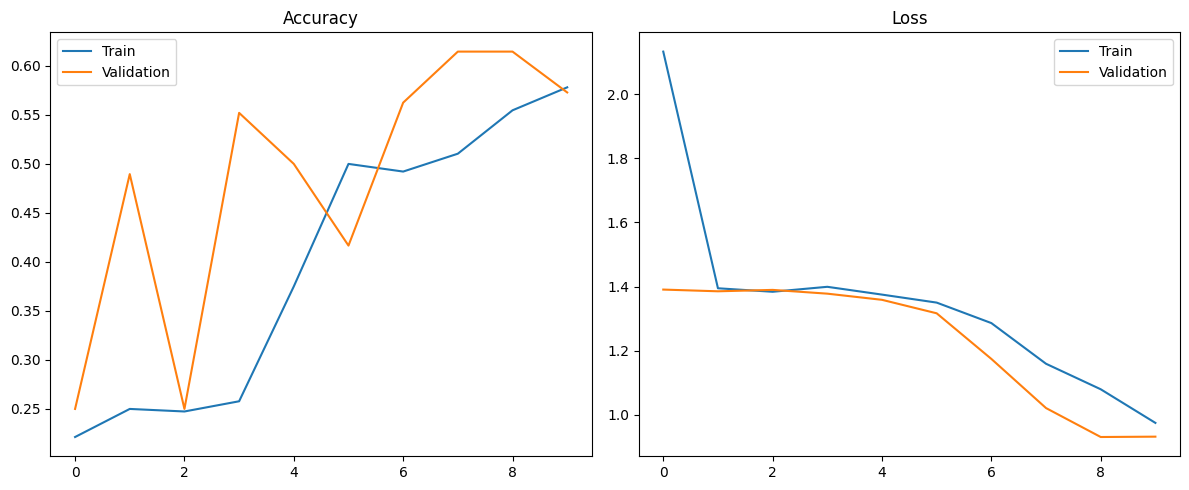

In [22]:
## Accuracy & loss curves
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()

os.makedirs("results", exist_ok=True)

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


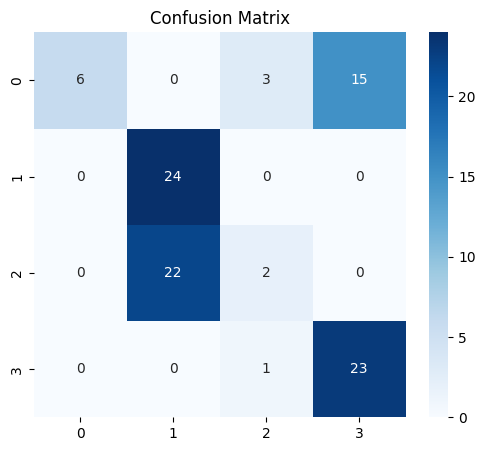

In [23]:
## Confusion matrix
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [24]:
## classification report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40        24
           1       0.52      1.00      0.69        24
           2       0.33      0.08      0.13        24
           3       0.61      0.96      0.74        24

    accuracy                           0.57        96
   macro avg       0.62      0.57      0.49        96
weighted avg       0.62      0.57      0.49        96



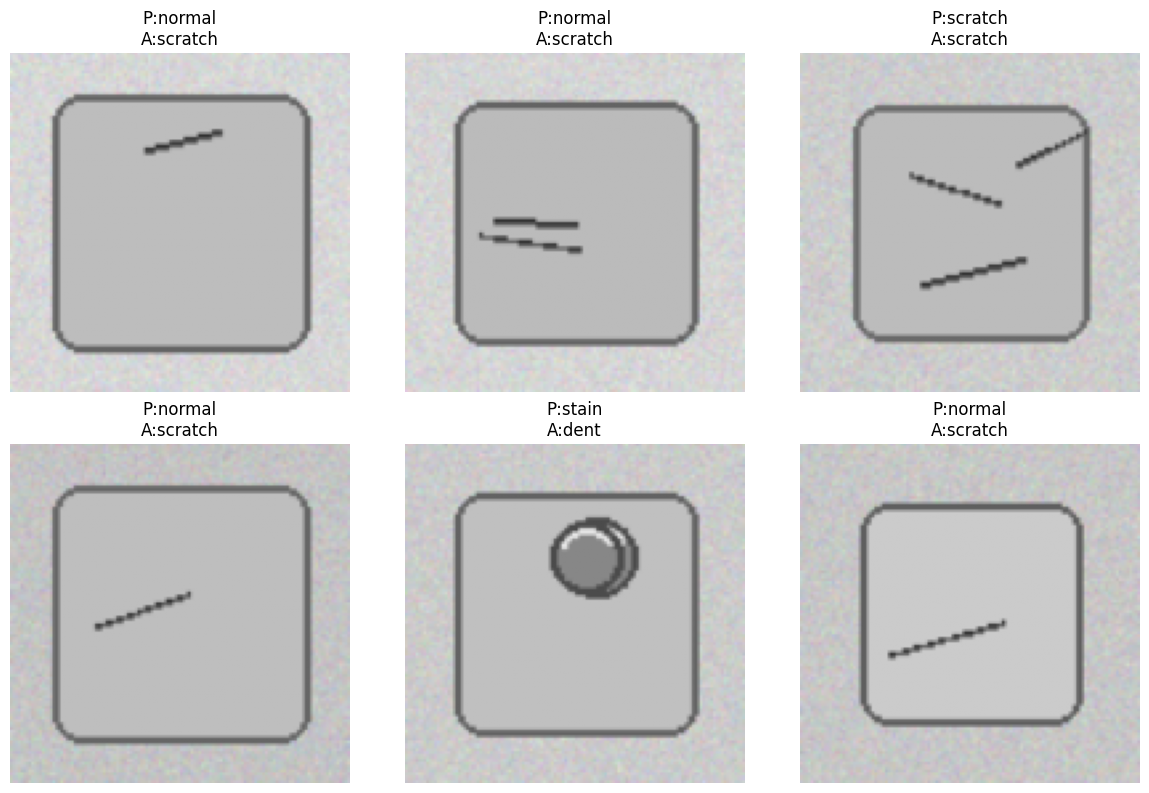

In [25]:
## sample predictions
os.makedirs("sample_predictions", exist_ok=True)

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    pred = encoder.inverse_transform([y_pred_classes[i]])[0]
    actual = encoder.inverse_transform([y_test[i]])[0]

    plt.title(f"P:{pred}\nA:{actual}")

    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Task 6
# CNN Concepts

## What is Convolution?
Convolution is the process of applying filters to images to detect patterns such as edges, textures, and shapes.

## Why is Pooling Used?
Pooling reduces image dimensions while preserving important features. This decreases computation and helps reduce overfitting.

## Why is ReLU Commonly Used?
ReLU introduces non-linearity and helps CNNs learn complex visual patterns efficiently.

## Why are CNNs Better Than Feed-Forward Networks for Images?
CNNs preserve spatial relationships in images and automatically learn visual features, making them far more effective for image data.

# Task 7
# Business Use Case

This CNN-based defect detection system can be used in manufacturing quality inspection.

Example:
- Detect scratches, dents, and stains automatically
- Reduce manual inspection effort
- Improve production quality
- Increase consistency and speed in factory operations

Such systems are widely used in smart manufacturing and industrial automation.